<H1>Business Case: Netflix - Data Exploration and Visualisation</H1>

In [1]:
# Importing necessary Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# Importing Netflix Dataset

data = pd.read_csv(r"C:\Users\Aakash\Documents\netflix.csv")

In [3]:
data.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [4]:
# Basic info about dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


<h5>Summary:</h5>

The dataset contains 8,807 entries with 12 columns, including identifiers, titles, and content details for movies and TV shows on Netflix. Key columns include director, cast, country, and date_added, which have some missing values. The data is predominantly categorical with one numerical column, release_year, and includes metadata like ratings and genres.

<h3>Handling missing values</h3>

In [5]:
# Removing rows with missing values where null values are minimal
data.dropna(subset=['date_added','rating','duration'],inplace=True)

In [6]:
#filling nan values in country column using directors 
director_country_dict = {}

# Use zip to iterate through the 'Director' and 'Country' columns
for directors, country in zip(data['director'], data['country']):
    # Only process if the 'directors' value is a string (ignores NaN or floats)
    if isinstance(directors, str) and isinstance(country, str):
        # Split director names by comma and strip any whitespace
        for director in map(str.strip, directors.split(',')):
            # Only add the director if not already present in the dictionary
            director_country_dict.setdefault(director, country)
            
def fill_country_director(row):
    if pd.isna(row['country']):  # Check if 'Country' is NaN
        # Split the director names and check if any exist in the mapping dictionary
        if isinstance(row['director'], str):
            for director in map(str.strip, row['director'].split(',')):
                if director in director_country_dict:
                    return director_country_dict[director]
    return row['country']  # Return existing country if not NaN

# Apply the function to each row to fill NaN values in 'Country'
data['country'] = data.apply(fill_country_director, axis=1)

In [7]:
actor_country_dict = {}

# Use zip to iterate through the 'cast' and 'Country' columns
for actors, country in zip(data['cast'], data['country']):
    # Only process if the 'actors' value is a string (ignores NaN or floats)
    if isinstance(actors, str) and isinstance(country, str):
        # Split cast names by comma and strip any whitespace
        for actor in map(str.strip, actors.split(',')):
            # Only add the actor if not already present in the dictionary
            actor_country_dict.setdefault(actor, country)

def fill_country_cast(row):
    if pd.isna(row['country']):  # Check if 'Country' is NaN
        # Split the cast names and check if any exist in the mapping dictionary
        if isinstance(row['cast'], str):
            for actor in map(str.strip, row['cast'].split(',')):
                if actor in actor_country_dict:
                    return actor_country_dict[actor]
    return row['country']  # Return existing country if not NaN

# Apply the function to each row to fill NaN values in 'Country'
data['country'] = data.apply(fill_country_cast, axis=1)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      6169 non-null   object
 4   cast          7965 non-null   object
 5   country       8544 non-null   object
 6   date_added    8790 non-null   object
 7   release_year  8790 non-null   int64 
 8   rating        8790 non-null   object
 9   duration      8790 non-null   object
 10  listed_in     8790 non-null   object
 11  description   8790 non-null   object
dtypes: int64(1), object(11)
memory usage: 892.7+ KB


In [9]:
#Replacing Null values with 'Unknown' where there are huge number of missing values
data['director'].fillna("Unknown",inplace=True)
data['cast'].fillna("Unknown",inplace=True)
data['country'].fillna("Unknown",inplace=True)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   cast          8790 non-null   object
 5   country       8790 non-null   object
 6   date_added    8790 non-null   object
 7   release_year  8790 non-null   int64 
 8   rating        8790 non-null   object
 9   duration      8790 non-null   object
 10  listed_in     8790 non-null   object
 11  description   8790 non-null   object
dtypes: int64(1), object(11)
memory usage: 892.7+ KB


<h3>Handling Datatypes</h3>

In [11]:
# Convert 'date_added' to datetime format
data['date_added'] = pd.to_datetime(data['date_added'].str.strip(), format='%B %d, %Y')
data['type'] = data['type'].astype('category')
data['rating'] = data['rating'].astype('category')

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   category      
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   cast          8790 non-null   object        
 5   country       8790 non-null   object        
 6   date_added    8790 non-null   datetime64[ns]
 7   release_year  8790 non-null   int64         
 8   rating        8790 non-null   category      
 9   duration      8790 non-null   object        
 10  listed_in     8790 non-null   object        
 11  description   8790 non-null   object        
dtypes: category(2), datetime64[ns](1), int64(1), object(8)
memory usage: 773.3+ KB


<h3>Unnesting Data</h3>

In [13]:
# Split the 'director','cast','country' and 'listed_in' columns by comma
data['director'] = data['director'].str.split(',')
data['cast'] = data['cast'].str.split(',')
data['country'] = data['country'].str.split(',')
data['listed_in'] = data['listed_in'].str.split(',')

# Use explode on both columns
unnested_data = data.explode('director').explode('cast').explode('country').explode('listed_in').reset_index(drop=True)

# Split the 'director','cast','country' and 'listed_in' columns by comma
unnested_data['director'] = unnested_data['director'].str.strip()
unnested_data['cast'] = unnested_data['cast'].str.strip()
unnested_data['country'] = unnested_data['country'].str.strip()
unnested_data['listed_in'] = unnested_data['listed_in'].str.strip()

In [14]:
unnested_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
2,s2,TV Show,Blood & Water,Unknown,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
3,s2,TV Show,Blood & Water,Unknown,Ama Qamata,South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
4,s2,TV Show,Blood & Water,Unknown,Khosi Ngema,South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."


In [15]:
unnested_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203527 entries, 0 to 203526
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   show_id       203527 non-null  object        
 1   type          203527 non-null  category      
 2   title         203527 non-null  object        
 3   director      203527 non-null  object        
 4   cast          203527 non-null  object        
 5   country       203527 non-null  object        
 6   date_added    203527 non-null  datetime64[ns]
 7   release_year  203527 non-null  int64         
 8   rating        203527 non-null  category      
 9   duration      203527 non-null  object        
 10  listed_in     203527 non-null  object        
 11  description   203527 non-null  object        
dtypes: category(2), datetime64[ns](1), int64(1), object(8)
memory usage: 15.9+ MB


<h3>Feature Understanding</h3>

<h4> Type </h4>

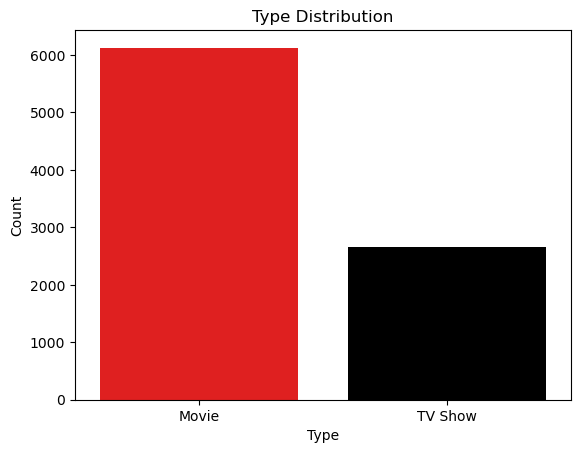

In [16]:
sns.countplot(data=data,x='type', palette=["red","black"])
plt.title('Type Distribution')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

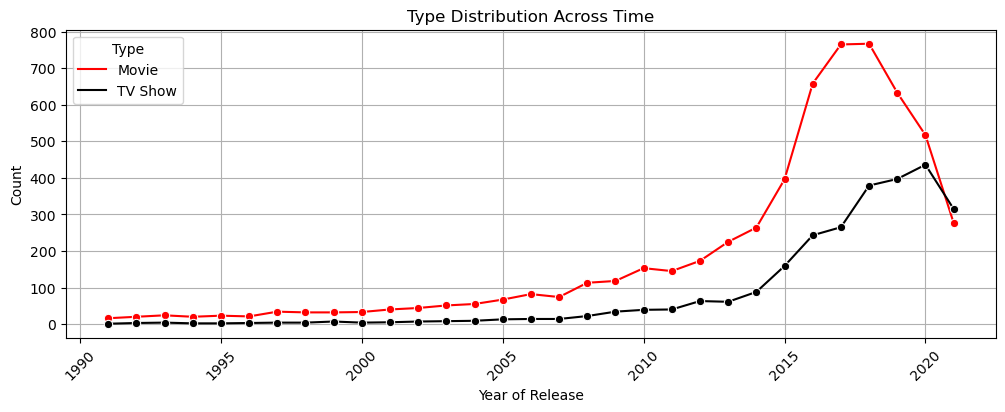

In [17]:
movies_by_date = data.groupby([data['release_year'], 'type'])['type'].count().reset_index(name='count')
movies_by_date = movies_by_date[movies_by_date['release_year'] > 1990]

plt.figure(figsize=(12, 4))
sns.lineplot(data=movies_by_date, x='release_year', y='count', hue='type', palette=["red", "black"], marker='o')

plt.xticks(rotation=45)
plt.title('Type Distribution Across Time')
plt.xlabel('Year of Release')
plt.ylabel('Count')
plt.legend(title='Type')  # Optional: add legend title if needed
plt.grid(True)  # Optional: add grid for better readability
plt.show()

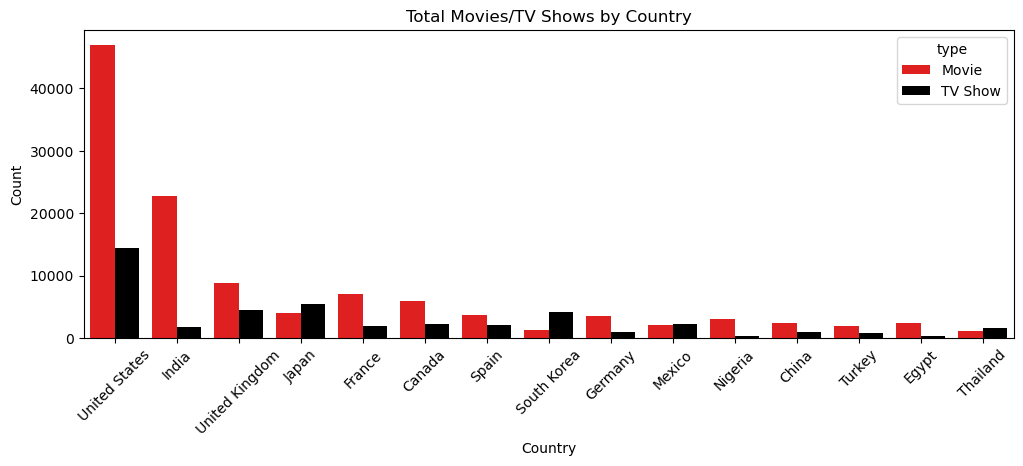

In [18]:
movies_by_country = unnested_data.groupby([unnested_data['country'], 'type'])['type'].count().reset_index(name='count')
movies_by_country['total'] = movies_by_country.groupby('country')['count'].transform('sum')
movies_by_country = movies_by_country.sort_values(by='total', ascending=False)[0:30]

# Plot the data
plt.figure(figsize=(12, 4))
sns.barplot(data=movies_by_country, x='country', y='count', hue='type', palette=["red","black"])
plt.xticks(rotation=45)
plt.title('Total Movies/TV Shows by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.show()

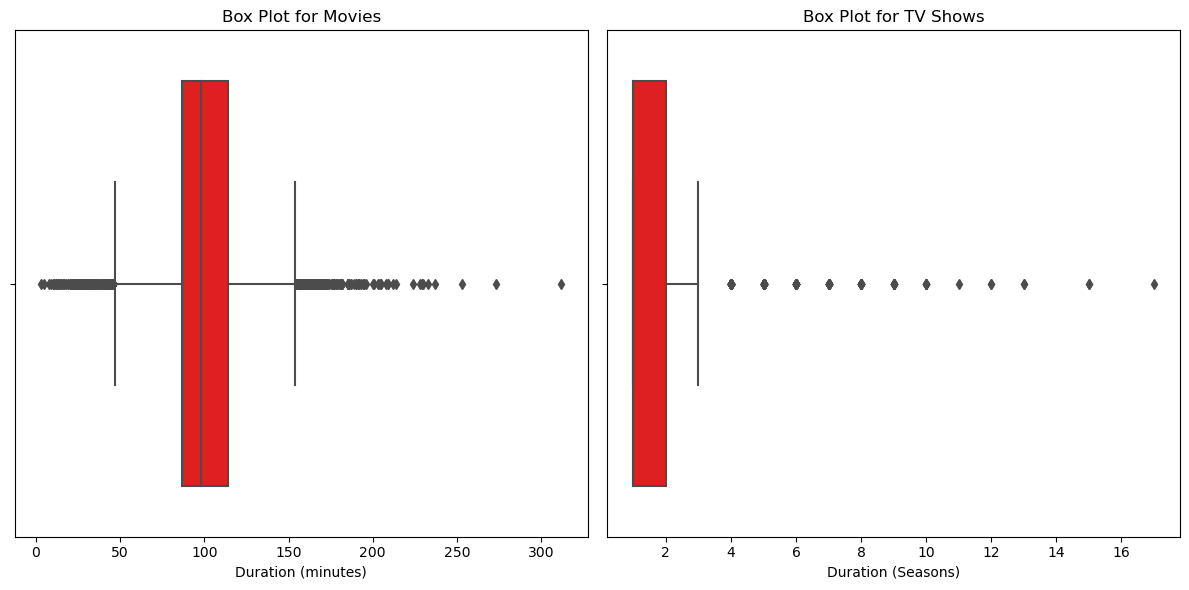

In [19]:
data['duration'] = data['duration'].str.replace(' Seasons', '')
data['duration'] = data['duration'].str.replace(' Season', '')
data['duration'] = data['duration'].str.replace(' min', '').astype(int)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Loop through unique types and create a box plot for each
sns.boxplot(x='duration', data=data[data['type'] == 'Movie'], ax=axes[0], palette=["red","black"])
axes[0].set_title(f'Box Plot for Movies')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('')

sns.boxplot(x='duration', data=data[data['type'] == 'TV Show'], ax=axes[1], palette=["red","black"])
axes[1].set_title(f'Box Plot for TV Shows')
axes[1].set_xlabel('Duration (Seasons)')
axes[1].set_ylabel('')

# Adjust layout
plt.tight_layout()
plt.show()

<h4> Directors </h4>

In [20]:
movies_df = unnested_data[unnested_data['type']=='Movie']
tvshow_df = unnested_data[unnested_data['type']=='TV Show']

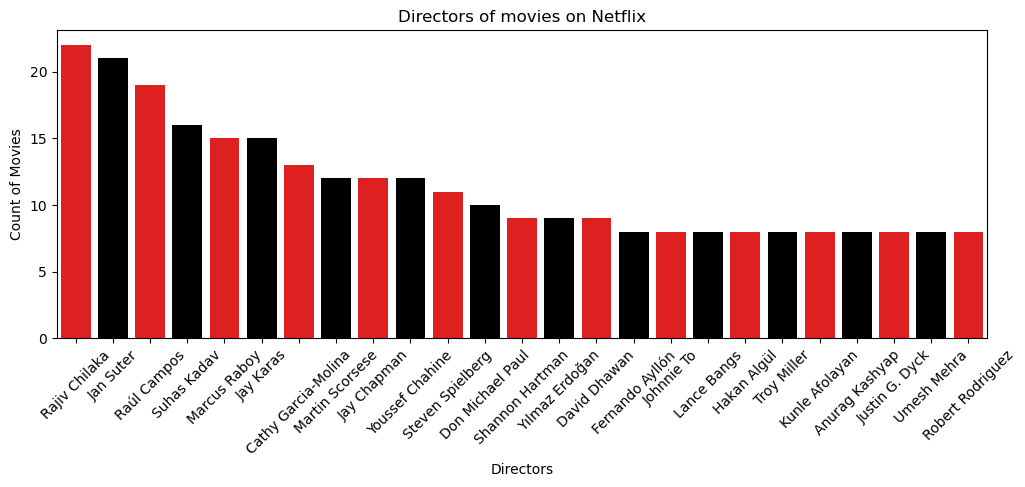

In [21]:
directors_movies_count = movies_df.groupby('director')['show_id'].nunique().reset_index(name='unique_count')
directors_movies_count = directors_movies_count.sort_values(by='unique_count', ascending=False)
directors_movies_count = directors_movies_count[directors_movies_count['director'] != 'Unknown'].head(25)

plt.figure(figsize=(12, 4))
sns.barplot(data=directors_movies_count,x='director',y='unique_count', palette=["red","black"])
plt.xticks(rotation=45)
plt.title('Directors of movies on Netflix')
plt.xlabel('Directors')
plt.ylabel('Count of Movies')
plt.show()

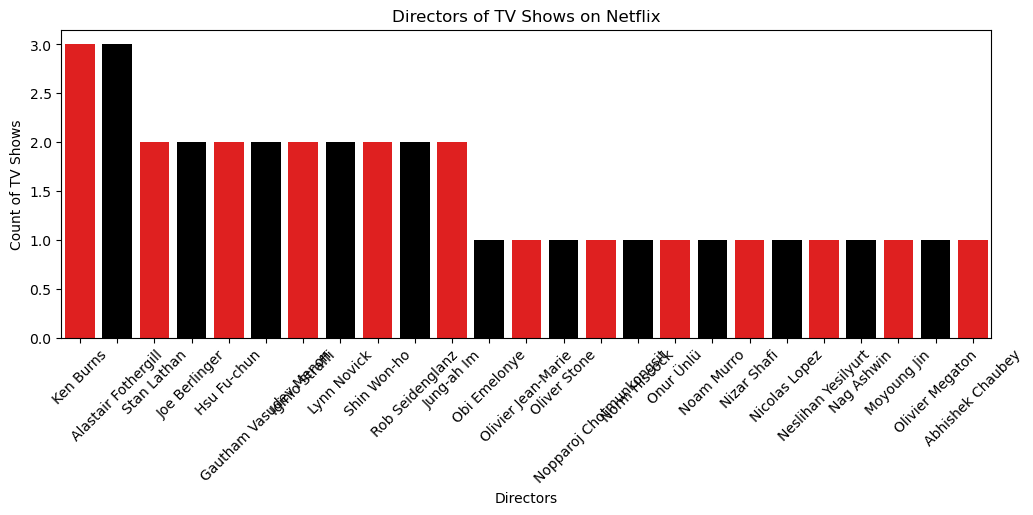

In [22]:
directors_tvshow_count = tvshow_df.groupby('director')['show_id'].nunique().reset_index(name='unique_count')
directors_tvshow_count = directors_tvshow_count.sort_values(by='unique_count', ascending=False)
directors_tvshow_count = directors_tvshow_count[directors_tvshow_count['director'] != 'Unknown'].head(25)

plt.figure(figsize=(12, 4))
sns.barplot(data=directors_tvshow_count,x='director',y='unique_count', palette=["red","black"])
plt.xticks(rotation=45)
plt.title('Directors of TV Shows on Netflix')
plt.xlabel('Directors')
plt.ylabel('Count of TV Shows')
plt.show()

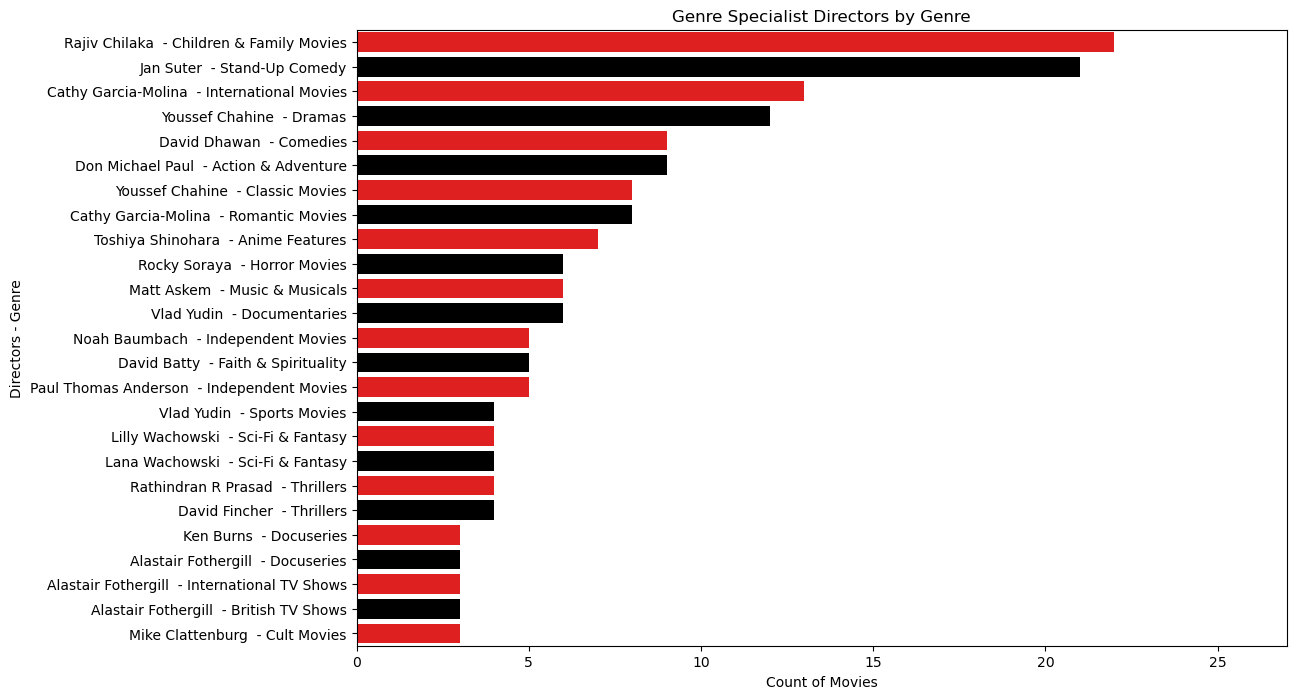

In [23]:
# Step 1: Create a DataFrame with unique combinations of director, listed_in, and title, excluding 'Unknown' directors
focussed_unnested_data = unnested_data[['director', 'listed_in', 'title']][unnested_data['director'] != 'Unknown'].drop_duplicates()

# Step 2: Group by director and listed_in, then count occurrences
df = focussed_unnested_data.groupby(['director', 'listed_in'])['listed_in'].count().reset_index(name='genre_count').sort_values(by='genre_count', ascending=False)

# Step 3: Find the maximum genre_count for each listed_in
max_genre_count = df.groupby('listed_in')['genre_count'].max().reset_index()

# Step 4: Merge to get associated directors for max counts
result = df.merge(max_genre_count, on=['listed_in', 'genre_count'], how='inner').head(25)

# Sort the result for plotting
data_sorted = result.sort_values(by='genre_count', ascending=False)
data_sorted['y_col'] = data_sorted['director'] + '  - ' + data_sorted['listed_in']

# Step 5: Create the bar plot
plt.figure(figsize=(12, 8))
bar_plot = sns.barplot(data=data_sorted, y='y_col', x='genre_count', palette=["red","black"])

plt.title('Genre Specialist Directors by Genre')
plt.ylabel('Directors - Genre')
plt.xlabel('Count of Movies')
plt.xlim(0, data_sorted['genre_count'].max() + 5)  # Adjust xlim to make room for annotations
plt.show()

<h4> Cast </h4>

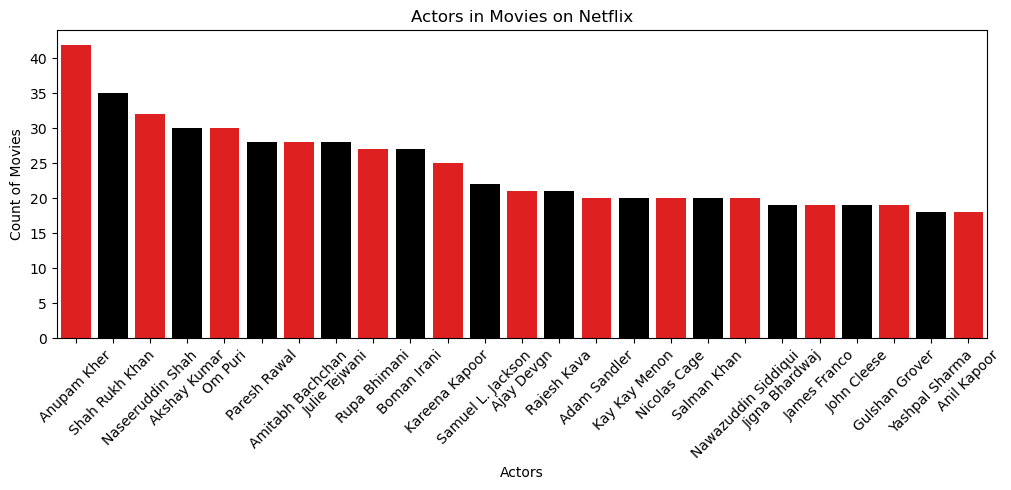

In [24]:
#cast_movies_count = movies_df.groupby(movies_df['director'])['show_id'].nunique().count().reset_index(name='count')
actors_movies_count = movies_df.groupby('cast')['show_id'].nunique().reset_index(name='unique_count')
actors_movies_count = actors_movies_count.sort_values(by='unique_count', ascending=False)
actors_movies_count = actors_movies_count[actors_movies_count['cast'] != 'Unknown'].head(25)

plt.figure(figsize=(12, 4))
sns.barplot(data=actors_movies_count,x='cast',y='unique_count', palette=["red","black"])
plt.xticks(rotation=45)
plt.title('Actors in Movies on Netflix')
plt.xlabel('Actors')
plt.ylabel('Count of Movies')
plt.show()

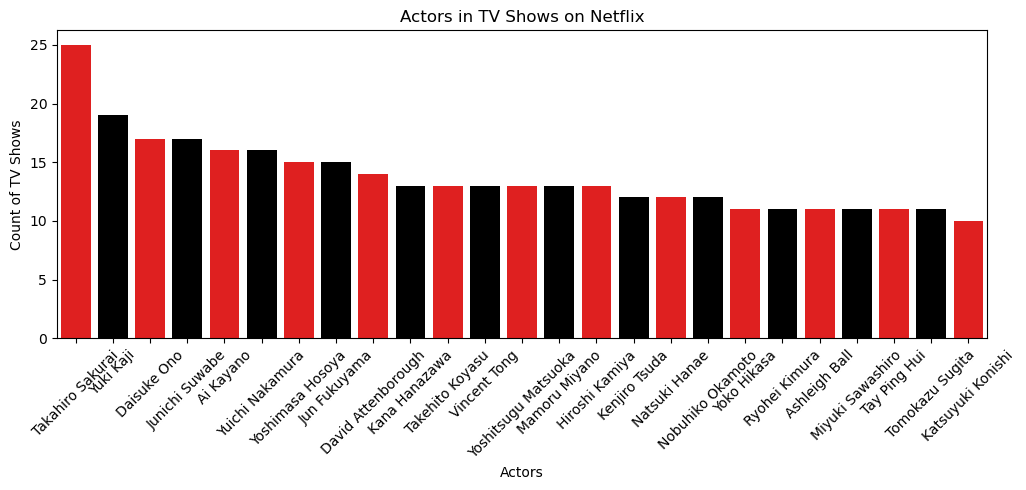

In [25]:
#actors_movies_count = movies_df.groupby(movies_df['cast'])['show_id'].nunique().count().reset_index(name='count')
actors_tvshow_count = tvshow_df.groupby('cast')['show_id'].nunique().reset_index(name='unique_count')
actors_tvshow_count = actors_tvshow_count.sort_values(by='unique_count', ascending=False)
actors_tvshow_count = actors_tvshow_count[actors_tvshow_count['cast'] != 'Unknown'].head(25)

plt.figure(figsize=(12, 4))
sns.barplot(data=actors_tvshow_count,x='cast',y='unique_count', palette=["red","black"])
plt.xticks(rotation=45)
plt.title('Actors in TV Shows on Netflix')
plt.xlabel('Actors')
plt.ylabel('Count of TV Shows')
plt.show()

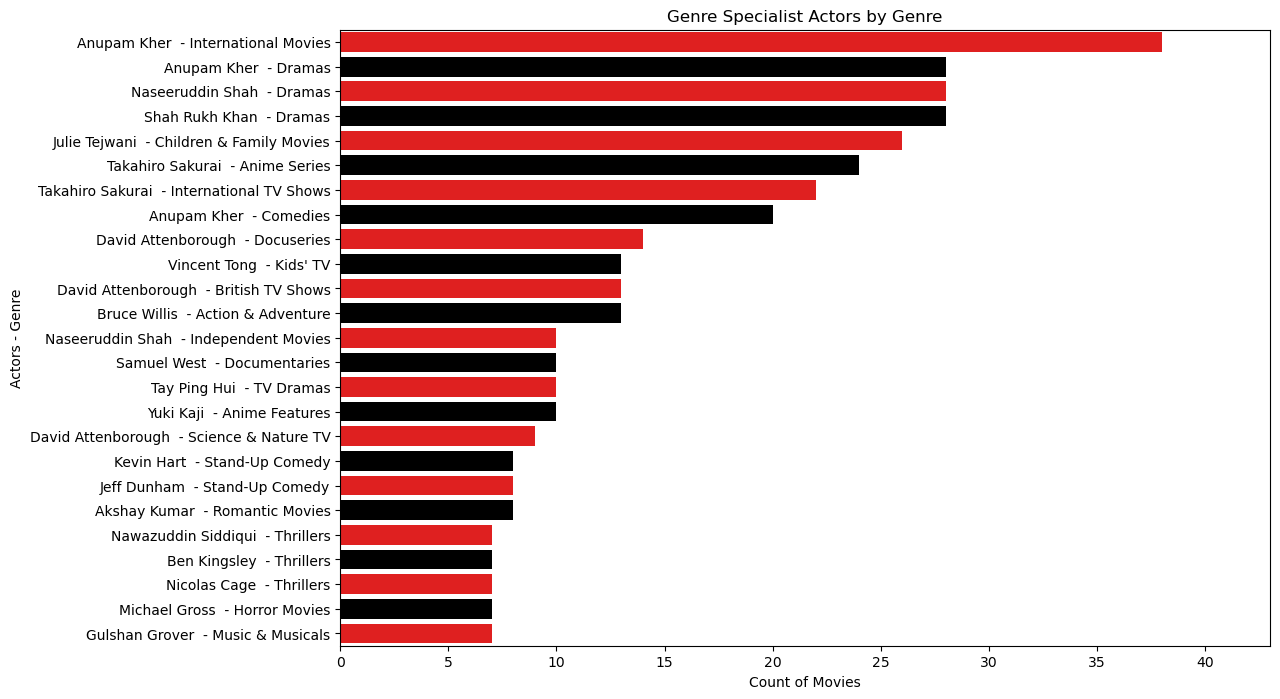

In [26]:
# Step 1: Create a DataFrame with unique combinations of director, listed_in, and title, excluding 'Unknown' directors
focussed_unnested_data = unnested_data[['cast', 'listed_in', 'title']][unnested_data['cast'] != 'Unknown'].drop_duplicates()

# Step 2: Group by director and listed_in, then count occurrences
df = focussed_unnested_data.groupby(['cast', 'listed_in'])['listed_in'].count().reset_index(name='genre_count').sort_values(by='genre_count', ascending=False)

# Step 3: Find the maximum genre_count for each listed_in
max_genre_count = df.groupby('listed_in')['genre_count'].max().reset_index()

# Step 4: Merge to get associated directors for max counts
result = df.merge(max_genre_count, on=['listed_in', 'genre_count'], how='inner').head(25)

# Sort the result for plotting
data_sorted = result.sort_values(by='genre_count', ascending=False)
data_sorted['y_col'] = data_sorted['cast'] + '  - ' + data_sorted['listed_in']

# Step 5: Create the bar plot
plt.figure(figsize=(12, 8))
bar_plot = sns.barplot(data=data_sorted, y='y_col', x='genre_count', palette=["red","black"])

# # Step 6: Add annotations for each bar
# for index, row in data_sorted.iterrows():
#     bar_plot.text(row['genre_count'] + 0.1, index, 
#                   f"{row['listed_in']}", 
#                   color='black', va="center", fontsize=10)

plt.title('Genre Specialist Actors by Genre')
plt.ylabel('Actors - Genre')
plt.xlabel('Count of Movies')
plt.xlim(0, data_sorted['genre_count'].max() + 5)  # Adjust xlim to make room for annotations
plt.show()

<h4> Country</h4>

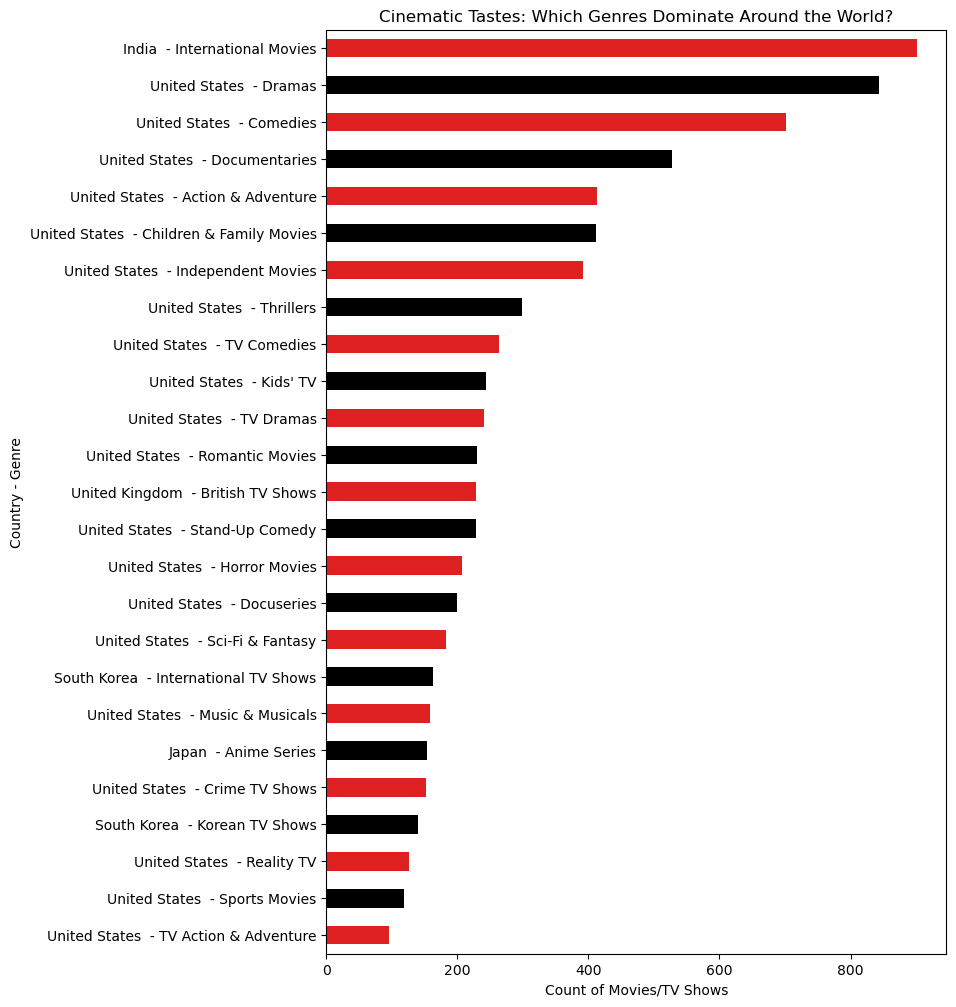

In [27]:
# Step 1: Create a DataFrame with unique combinations of director, listed_in, and title, excluding 'Unknown' directors
focussed_unnested_data = unnested_data[['country', 'listed_in', 'title']][unnested_data['country'] != 'Unknown'].drop_duplicates()

# Step 2: Group by director and listed_in, then count occurrences
df = focussed_unnested_data.groupby(['country', 'listed_in'])['listed_in'].count().reset_index(name='genre_count').sort_values(by='genre_count', ascending=False)

# Step 3: Find the maximum genre_count for each listed_in
max_genre_count = df.groupby('listed_in')['genre_count'].max().reset_index()

# Step 4: Merge to get associated directors for max counts
result = df.merge(max_genre_count, on=['listed_in', 'genre_count'], how='inner').head(25)

# Sort the result for plotting
data_sorted = result.sort_values(by='genre_count', ascending=False)
data_sorted['y_col'] = data_sorted['country'] + '  - ' + data_sorted['listed_in']

# Step 5: Create the bar plot
plt.figure(figsize=(8,12)) 
bar_plot = sns.barplot(data=data_sorted, y='y_col', x='genre_count', palette=["red","black"], width=0.5)

# for index, row in data_sorted.iterrows():
#     # Adjust the annotation position based on the genre_count
#     bar_plot.text(row['genre_count'] + 0.1, index, 
#                   f"{row['listed_in']}", 
#                   color='black', va="center", fontsize=9)

plt.title('Cinematic Tastes: Which Genres Dominate Around the World?')
plt.xlabel('Count of Movies/TV Shows')
plt.ylabel('Country - Genre')
plt.show()

<h4>Rating</h4>

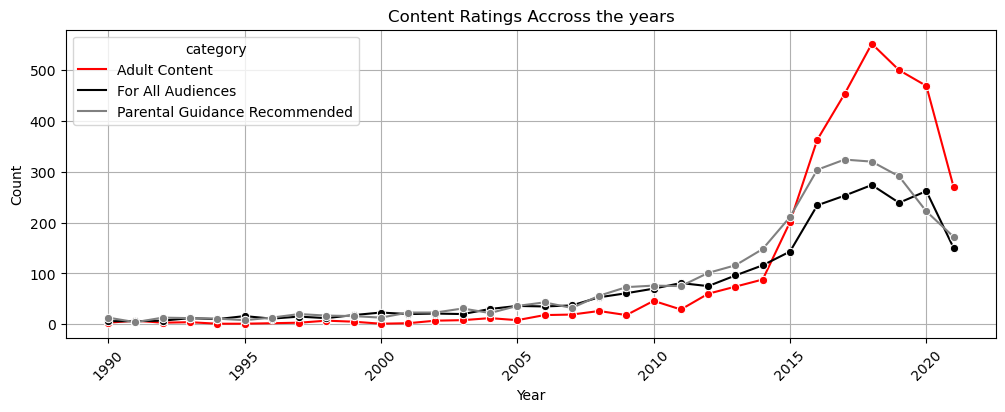

In [28]:
df_rating = unnested_data[['title','rating','release_year']].drop_duplicates()

#Categorizing the types of Ratings given to movies
def categorize_rating(rating):
    if rating in ['G', 'PG', 'PG-13', 'TV-Y', 'TV-Y7', 'TV-G', 'TV-PG']:
        return 'For All Audiences'
    elif rating in ['PG-13', 'R', 'TV-14']:
        return 'Parental Guidance Recommended'
    elif rating in ['NC-17', 'NR', 'TV-MA', 'UR', 'TV-Y7-FV']:
        return 'Adult Content'
    else:
        return 'Unknown'

# Apply the function to create a new column for categories
df_rating['category'] = df_rating['rating'].apply(categorize_rating)

df_rating_agg = pd.DataFrame(df_rating.groupby(['release_year','category'])['title'].count().reset_index())
df_rating_agg = df_rating_agg[df_rating_agg['release_year']>=1990]

plt.figure(figsize=(12, 4))
sns.lineplot(data=df_rating_agg, x='release_year', y='title', hue='category', palette=["red", "black","grey"], marker='o')

plt.xticks(rotation=45)
plt.title('Content Ratings Accross the years')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='category')  # Optional: add legend title if needed
plt.grid(True)  # Optional: add grid for better readability
plt.show()

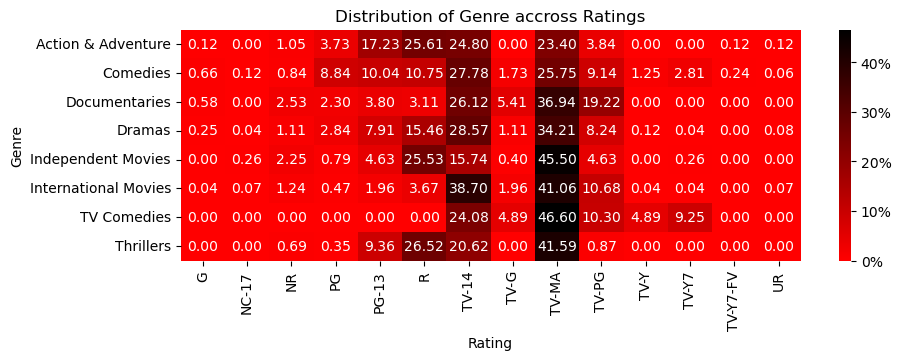

In [33]:
df_genre_rating = unnested_data[['listed_in','title','rating']].drop_duplicates()
df_genre_rating = df_genre_rating[df_genre_rating['listed_in'].isin(['International Movies', 'Dramas', 'Comedies', 'Documentaries', 'Action & Adventure','Independent Movies','Thrillers','TV Comedies'])]
df_genre_rating_agg = pd.DataFrame(df_genre_rating.groupby(['listed_in','rating'])['title'].count()).reset_index()
df_genre_rating_agg['ratio'] = round((df_genre_rating_agg['title'] / df_genre_rating_agg.groupby('listed_in')['title'].transform('sum'))*100,2)

# Create a custom colormap (red to black)
red_black_cmap = LinearSegmentedColormap.from_list('RedBlack', ['red', 'black'])

# Pivot the data to create a matrix format for the heatmap
heatmap_data = df_genre_rating_agg.pivot(index='listed_in', columns='rating', values='ratio')

# Create the heatmap
plt.figure(figsize=(10, 3))
sns.heatmap(heatmap_data, annot=True, cmap=red_black_cmap, fmt='.2f', cbar_kws={'format': '%.0f%%'})

# Add labels and title
plt.xlabel('Rating')
plt.ylabel('Genre')
plt.title('Distribution of Genre accross Ratings')

# Show the plot
plt.show()

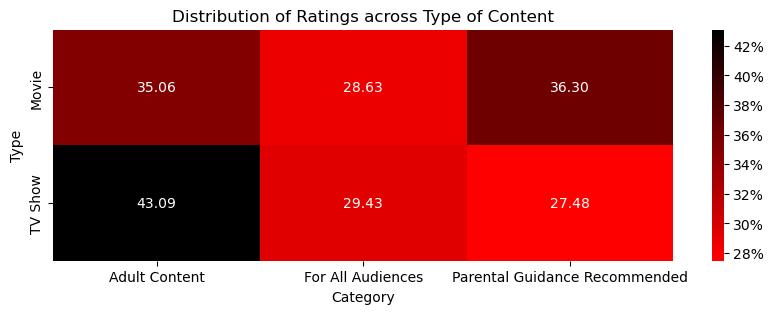

In [34]:
df_rating = data[['type','title','rating']].drop_duplicates()
df_rating['category'] = df_rating['rating'].apply(categorize_rating)

df_rating_agg = pd.DataFrame(df_rating.groupby(['type','category'])['title'].count()).reset_index()
df_rating_agg['ratio'] = round((df_rating_agg['title'] / df_rating_agg.groupby('type')['title'].transform('sum'))*100,2)

# Pivot the data to create a matrix format for the heatmap
heatmap_data = df_rating_agg.pivot(index='type', columns='category', values='ratio')

# Create the heatmap
plt.figure(figsize=(10, 3))
sns.heatmap(heatmap_data, annot=True, cmap=red_black_cmap, fmt='.2f', cbar_kws={'format': '%.0f%%'})

# Add labels and title
plt.xlabel('Category')
plt.ylabel('Type')
plt.title('Distribution of Ratings across Type of Content')

# Show the plot
plt.show()

<h4>Added in (Adoption of Platform)</h4>

In [31]:
df_addedin = unnested_data
df_addedin['date_added'] = df_addedin['date_added'].dt.year

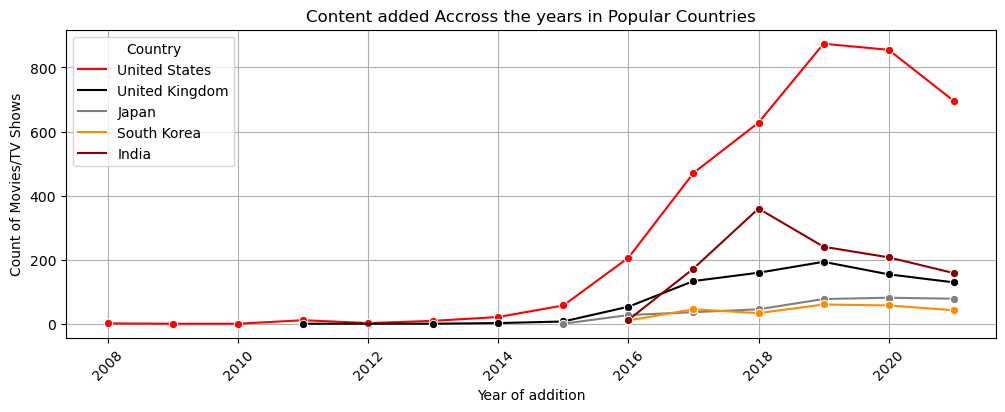

In [32]:
df_added_country = df_addedin[['title','country','date_added']].drop_duplicates()
df_added_country_agg = pd.DataFrame(df_added_country.groupby(['country','date_added'])['title'].count().reset_index()).sort_values(by='date_added')
df_added_country_agg = df_added_country_agg[df_added_country_agg['country'].isin(['India', 'United States', 'United Kingdom', 'South Korea', 'Japan'])]

plt.figure(figsize=(12, 4))
sns.lineplot(data=df_added_country_agg, x='date_added', y='title', hue='country', palette=["red", "black","grey","darkorange","darkred"], marker='o')

plt.xticks(rotation=45)
plt.title('Content added Accross the years in Popular Countries')
plt.xlabel('Year of addition')
plt.ylabel('Count of Movies/TV Shows')
plt.legend(title='Country')  # Optional: add legend title if needed
plt.grid(True)  # Optional: add grid for better readability
plt.show()